# 18-1 · Naive Bayes con Variables Numéricas

Naive Bayes estándar (`CategoricalNB`) solo funciona con variables categóricas. Pero ahora tenemos `temperatura` — un número continuo. ¿Cómo lo manejamos?

Dos enfoques:
1. **Binning** — convertir el número a categorías (frío/templado/caliente) y usar `CategoricalNB`
2. **Distribución normal** — asumir que la temperatura sigue una campana de Gauss y usar `GaussianNB`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/friends.csv")
print(df.head(10))
print(f"\nShape: {df.shape}")

  con_novia llueve viernes sale  temperatura  hora_invitacion
0        Sí     Sí      No   No         21.7             20.0
1        No     No      No   No         18.9             18.8
2        No     Sí      Sí   Sí         26.6             15.6
3        No     No      Sí   Sí         30.1             17.8
4        Sí     Sí      Sí   Sí         23.1             13.4
5        Sí     No      Sí   Sí         23.1             13.4
6        Sí     No      No   No         15.7             17.6
7        No     No      No   No         23.3             20.6
8        No     No      No   Sí         22.1             12.8
9        No     Sí      No   Sí         26.2             15.4

Shape: (40, 6)


## 1 · El Problema: Temperatura es Numérica

No podemos contar $P(\text{temperatura}=22.1 | \text{sale}=\text{Sí})$ porque 22.1 probablemente aparece una sola vez (o cero). Los números continuos no se repiten.

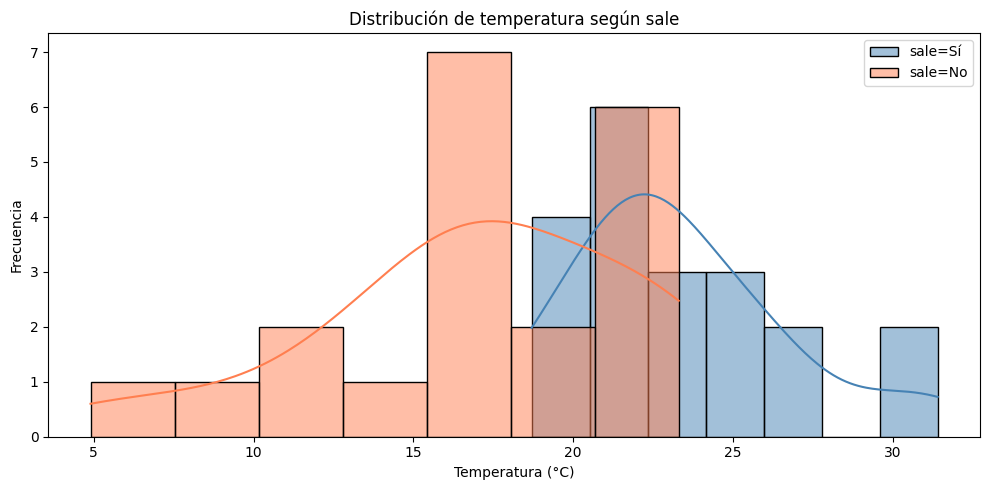

Temperatura promedio cuando sale:    23.4°C
Temperatura promedio cuando no sale: 17.0°C


In [2]:
# Distribución de temperatura según si sale o no
fig, ax = plt.subplots(figsize=(10, 5))

for clase, color in [("Sí", "steelblue"), ("No", "coral")]:
    subset = np.array(df[df["sale"] == clase]["temperatura"])

    sns.histplot(
        subset, ax=ax, color=color, alpha=0.5, kde=True, label=f"sale={clase}", bins=7
    )

ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de temperatura según sale")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Temperatura promedio cuando sale:    {df[df['sale'] == 'Sí']['temperatura'].mean():.1f}°C"
)
print(
    f"Temperatura promedio cuando no sale: {df[df['sale'] == 'No']['temperatura'].mean():.1f}°C"
)

## 2 · Enfoque 1: Binning

Convertir temperatura a categorías: **frío** (< 15°C), **templado** (15-22°C), **caliente** (> 22°C). Ahora podemos contar frecuencias.

In [3]:
TEMP_LABELS = ["frío", "templado", "caliente"]

# pd.cut convierte números a categorías usando rangos
df["temp_bin"] = pd.cut(df["temperatura"], bins=[0, 15, 22, 40], labels=TEMP_LABELS)

print(pd.crosstab(df["temp_bin"], df["sale"], margins=True))
print()
print("Cuando sale → más caliente. Cuando no sale → más frío.")

sale      No  Sí  All
temp_bin             
frío       5   0    5
templado  11   7   18
caliente   4  13   17
All       20  20   40

Cuando sale → más caliente. Cuando no sale → más frío.


In [4]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ["con_novia", "llueve", "viernes", "temp_bin"]
YES_NO = ["No", "Sí"]

enc = OrdinalEncoder(categories=[YES_NO, YES_NO, YES_NO, TEMP_LABELS])
X_bin = enc.fit_transform(df[cat_cols])

enc_y = OrdinalEncoder(categories=[YES_NO])
y = enc_y.fit_transform(df[["sale"]]).ravel()

nb_bin = CategoricalNB(alpha=1e-10)
nb_bin.fit(X_bin, y)

# Escenario: con_novia=Sí, llueve=No, viernes=Sí, temperatura=25°C → "caliente"
escenario = pd.DataFrame([["Sí", "No", "Sí", "caliente"]], columns=cat_cols)
proba_bin = nb_bin.predict_proba(enc.transform(escenario))[0]

print(f"Enfoque Binning (CategoricalNB):")
print(
    f"  P(sale=Sí | con_novia=Sí, llueve=No, viernes=Sí, temp=caliente) = {proba_bin[1]:.2%}"
)

Enfoque Binning (CategoricalNB):
  P(sale=Sí | con_novia=Sí, llueve=No, viernes=Sí, temp=caliente) = 77.57%


## 3 · Enfoque 2: Distribución Normal (GaussianNB)

En vez de convertir a categorías, asumimos que la temperatura sigue una **distribución normal** (campana de Gauss) para cada clase.

`GaussianNB` calcula la media y desviación estándar de cada predictor numérico por clase, y usa la curva normal para estimar $P(X | Y)$:

$$P(x | Y=i) = \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left(-\frac{(x - \mu_i)^2}{2\sigma_i^2}\right)$$

No necesitas memorizar la fórmula — lo importante es que usa la **campana** en vez de contar.

sale=Sí: media=23.4°C, std=3.3°C
sale=No: media=17.0°C, std=5.0°C


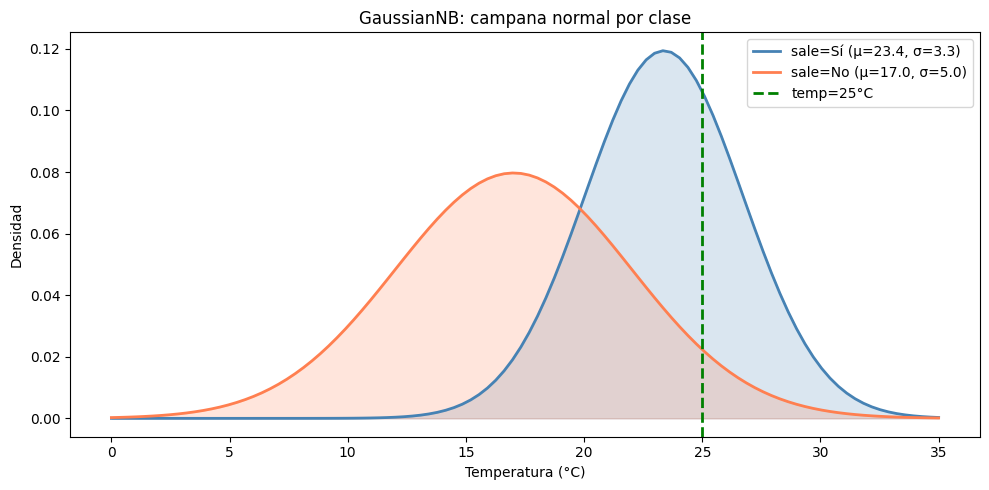


→ A 25°C, la campana azul (Sí) es más alta que la roja (No)
  Eso significa P(temp=25 | sale=Sí) > P(temp=25 | sale=No)


In [5]:
# Lo que GaussianNB hace internamente: calcular media y std por clase
for clase in ["Sí", "No"]:
    temp = df[df["sale"] == clase]["temperatura"]
    print(f"sale={clase}: media={temp.mean():.1f}°C, std={temp.std():.1f}°C")

# Visualizar las campanas
fig, ax = plt.subplots(figsize=(10, 5))
x_range = np.linspace(0, 35, 100)

for clase, color in [("Sí", "steelblue"), ("No", "coral")]:
    temp = df[df["sale"] == clase]["temperatura"]
    mu, sigma = temp.mean(), temp.std()
    # Curva normal
    from scipy.stats import norm

    ax.plot(
        x_range,
        norm.pdf(x_range, mu, sigma),
        color=color,
        linewidth=2,
        label=f"sale={clase} (μ={mu:.1f}, σ={sigma:.1f})",
    )
    ax.fill_between(x_range, norm.pdf(x_range, mu, sigma), alpha=0.2, color=color)

ax.axvline(25, color="green", linestyle="--", linewidth=2, label="temp=25°C")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Densidad")
ax.set_title("GaussianNB: campana normal por clase")
ax.legend()
plt.tight_layout()
plt.show()

print("\n→ A 25°C, la campana azul (Sí) es más alta que la roja (No)")
print("  Eso significa P(temp=25 | sale=Sí) > P(temp=25 | sale=No)")

In [6]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB trata TODOS los predictores como numéricos
# Codificamos las categóricas como 0/1 y dejamos temperatura como está
X_gauss = df[["con_novia", "llueve", "viernes", "temperatura"]].copy()
X_gauss["con_novia"] = (X_gauss["con_novia"] == "Sí").astype(int)
X_gauss["llueve"] = (X_gauss["llueve"] == "Sí").astype(int)
X_gauss["viernes"] = (X_gauss["viernes"] == "Sí").astype(int)

nb_gauss = GaussianNB()
nb_gauss.fit(X_gauss, y)

# Mismo escenario: con_novia=1, llueve=0, viernes=1, temperatura=25
escenario_gauss = np.array([[1, 0, 1, 25]])
proba_gauss = nb_gauss.predict_proba(escenario_gauss)[0]

print(f"Enfoque Gaussiano (GaussianNB):")
print(
    f"  P(sale=Sí | con_novia=Sí, llueve=No, viernes=Sí, temp=25°C) = {proba_gauss[1]:.2%}"
)

Enfoque Gaussiano (GaussianNB):
  P(sale=Sí | con_novia=Sí, llueve=No, viernes=Sí, temp=25°C) = 86.45%


/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


## 4 · Comparación: Binning vs Gaussiano

¿Cambia la predicción según el enfoque? Veamos para varias temperaturas.

In [7]:
# Escenario fijo: con_novia=Sí, llueve=No, viernes=Sí, variando temperatura
temps = [5, 10, 15, 20, 25, 30]
results = []

for t in temps:
    # Binning
    if t < 15:
        bin_label = "frío"
    elif t <= 22:
        bin_label = "templado"
    else:
        bin_label = "caliente"

    x_bin = enc.transform(
        pd.DataFrame([["Sí", "No", "Sí", bin_label]], columns=cat_cols)
    )
    p_bin = nb_bin.predict_proba(x_bin)[0][1]

    # Gaussiano
    p_gauss = nb_gauss.predict_proba(np.array([[1, 0, 1, t]]))[0][1]

    results.append(
        {
            "temp": f"{t}°C",
            "bin": bin_label,
            "P(Sí) binning": f"{p_bin:.1%}",
            "P(Sí) gauss": f"{p_gauss:.1%}",
        }
    )

print(pd.DataFrame(results).to_string(index=False))

temp      bin P(Sí) binning P(Sí) gauss
 5°C     frío          0.0%        0.0%
10°C     frío          0.0%        0.1%
15°C templado         40.4%        7.0%
20°C templado         40.4%       57.2%
25°C caliente         77.6%       86.5%
30°C caliente         77.6%       89.2%


/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/angelozdev/me/practical-stati

### Observaciones

- **Binning**: la probabilidad cambia en "escalones" — 5°C y 10°C dan lo mismo porque ambos caen en "frío"
- **Gaussiano**: la probabilidad cambia suavemente con cada grado — 5°C es distinto de 10°C
- Gaussiano aprovecha mejor la información numérica, pero asume que los datos siguen una campana normal

## 5 · Laplace Smoothing

¿Qué pasa si una categoría tiene **cero** observaciones para una clase? La probabilidad sería 0, y al multiplicar todo se va a 0.

**Laplace smoothing** suma un conteo ficticio (por defecto `alpha=1`) a cada categoría para evitar ceros.

In [8]:
# Ejemplo: P(temp_bin=frío | sale=Sí)
n_frio_si = ((df["temp_bin"] == "frío") & (df["sale"] == "Sí")).sum()
n_si = (df["sale"] == "Sí").sum()
n_categorias = 3  # frío, templado, caliente

print(
    f"Sin smoothing:  P(frío | sale=Sí) = {n_frio_si}/{n_si} = {n_frio_si / n_si:.3f}"
)

# Con Laplace: sumamos alpha=1 al numerador y alpha*n_categorias al denominador
alpha = 1
p_laplace = (n_frio_si + alpha) / (n_si + alpha * n_categorias)
print(
    f"Con smoothing:  P(frío | sale=Sí) = ({n_frio_si}+1)/({n_si}+3) = {p_laplace:.3f}"
)
print(
    f"\n→ Si n_frio_si fuera 0, sin smoothing da 0 (mata todo). Con smoothing da {alpha / (n_si + alpha * n_categorias):.3f} (sobrevive)."
)

Sin smoothing:  P(frío | sale=Sí) = 0/20 = 0.000
Con smoothing:  P(frío | sale=Sí) = (0+1)/(20+3) = 0.043

→ Si n_frio_si fuera 0, sin smoothing da 0 (mata todo). Con smoothing da 0.043 (sobrevive).


## 6 · Resumen

| Enfoque | Cómo maneja numéricos | Ventaja | Limitación |
|---------|----------------------|---------|------------|
| **Binning** + `CategoricalNB` | Convierte a categorías (frío/templado/caliente) | Simple, sin supuestos | Pierde detalle (5°C = 10°C) |
| **GaussianNB** | Asume distribución normal por clase | Usa el valor exacto | Asume campana (puede ser falso) |
| **Laplace Smoothing** | Suma conteo ficticio (`alpha`) | Evita probabilidades de 0 | Sesga levemente las probabilidades |

| Cuándo usar qué |  |
|------------------|--|
| Variables categóricas | `CategoricalNB` |
| Variables numéricas con distribución normal | `GaussianNB` |
| Mezcla de ambas | Binning + `CategoricalNB` o codificar todo numérico + `GaussianNB` |

> 👈 En la práctica, `GaussianNB` es más común porque evita la decisión arbitraria de dónde poner los cortes del binning.